# Live Coding


1. Setup

* “Vamos a comparar probabilidad teórica vs simulación. Si repetimos muchas veces, las frecuencias se acercan a la teoría.”

In [ ]:
import numpy as np
import pandas as pd
from itertools import product

rng = np.random.default_rng(42)  # reproducible


2. Simulamos el lanzamiento de un dado y una moneda

In [ ]:
# Una corrida
moneda = rng.choice(["C", "S"])      # C=cara, S=sello
dado = rng.integers(1, 7)            # 1..6
(moneda, dado)


(np.str_('C'), np.int64(6))

3. Representamos el espacio muestral combinado

* El espacio muestral son todos los pares (moneda, dado)

In [ ]:
S = list(product(["C", "S"], range(1, 7)))
S, len(S)


([('C', 1),
  ('C', 2),
  ('C', 3),
  ('C', 4),
  ('C', 5),
  ('C', 6),
  ('S', 1),
  ('S', 2),
  ('S', 3),
  ('S', 4),
  ('S', 5),
  ('S', 6)],
 12)

["C","S"] son los posibles resultados de la moneda: Cara (C) o Sello (S).

range(1,7) genera los posibles resultados del dado: 1, 2, 3, 4, 5, 6 (ojo: el 7 no se incluye).

product(...) (de itertools) arma el producto cartesiano: todas las combinaciones posibles entre moneda y dado.

4. Calculamos probabilidades simples

Teórica

In [ ]:
A = [(m, d) for (m, d) in S if d % 2 == 1]  # dado impar
A, len(A), len(S), len(A)/len(S)


([('C', 1), ('C', 3), ('C', 5), ('S', 1), ('S', 3), ('S', 5)], 6, 12, 0.5)

Simulada

In [ ]:
N = 10000
monedas = rng.choice(["C", "S"], size=N)
dados = rng.integers(1, 7, size=N)

df = pd.DataFrame({"moneda": monedas, "dado": dados})
p_sim_impar = (df["dado"] % 2 == 1).mean()
p_sim_impar


np.float64(0.5025)

5. Regla del producto en eventos sucesivos

Define dos eventos:
* B: “¿Salió cara?”
* C: “¿Salió 6?”

P(B∩C)=P(B)⋅P(C)= (1/2) * (1/6)​= 1/12​

Teórica:

In [ ]:
p_teo = (1/2) * (1/6)
p_teo


0.08333333333333333

Simulada:

In [ ]:
p_sim = ((df["moneda"] == "C") & (df["dado"] == 6)).mean()
p_sim


np.float64(0.0787)

6. Usamos random/numpy para reproducir experimentos múltiples (y ver convergencia)

In [ ]:
def sim_prob(N, seed=42):
    r = np.random.default_rng(seed)
    monedas = r.choice(["C", "S"], size=N)
    dados = r.integers(1, 7, size=N)
    return ((monedas == "C") & (dados == 6)).mean()

Ns = [10, 50, 100, 500, 1000, 10000]
tabla = pd.DataFrame({
    "N": Ns,
    "P_sim(C y 6)": [sim_prob(n) for n in Ns],
    "P_teo(C y 6)": [1/12]*len(Ns)
})
tabla


,N,P_sim(C y 6),P_teo(C y 6)
0,10,0.1000,0.083333
1,50,0.0400,0.083333
2,100,0.0400,0.083333
3,500,0.0880,0.083333
4,1000,0.0980,0.083333
5,10000,0.0787,0.083333


7. Árbol de probabilidades para organizar resultados

* Nivel 1: C (1/2), S (1/2)
* Nivel 2 desde cada rama: 1..6 (1/6 cada uno)

Cada hoja=1/12 x 1/2 = 1/12

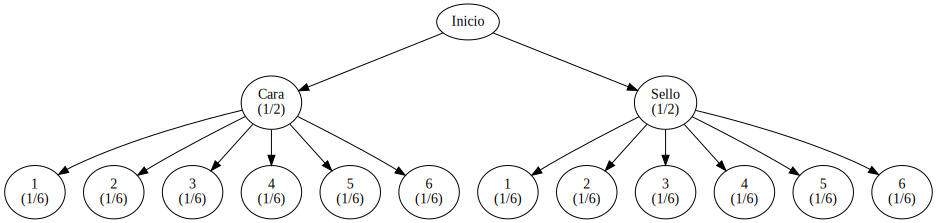

In [ ]:
from graphviz import Digraph

dot = Digraph()
dot.node("I", "Inicio")

dot.node("C", "Cara\n(1/2)")
dot.node("S", "Sello\n(1/2)")
dot.edge("I", "C")
dot.edge("I", "S")

for i in range(1, 7):
    dot.node(f"C{i}", f"{i}\n(1/6)")
    dot.node(f"S{i}", f"{i}\n(1/6)")
    dot.edge("C", f"C{i}")
    dot.edge("S", f"S{i}")

dot


8.Cierre:

En los datos reales, la aleatoriedad no significa falta de sentido, sino variabilidad natural.
Nuestro objetivo como analistas no es eliminarla, sino comprenderla y modelarla para extraer información confiable.


En Data Science, los datos nunca son perfectamente determinísticos.
La presencia de aleatoriedad es inevitable, y reconocerla es clave para interpretar resultados, estimar incertidumbre y tomar decisiones informadas

# Ejercicio 1

## 1) Definimos eventos

**Evento real**

F: la transacción sí es fraude

¬F: la transacción no es fraude


**Evento del modelo (predicción):**

M: el modelo indica “Fraude”

¬M: el modelo indica “No Fraude”

Parámetros del ejercicio:

- \(P(F)=0.10\)
- \(P(¬F)=0.90\) = 1 - \(P(F)=0.10\)
- \(P(M | F)=0.90\)  (sensibilidad / recall) ¿Qué tan bien detecto los fraudes que existen?
- \(P(M | ¬F)=0.05\) (falso positivo)


*De todas las transacciones, solo un 10% son realmente fraude.*

En notación:
* P(F) = 0.10
* P(¬F) = 0.90

*Probabilidad de que el modelo lo detecte como fraude si lo es (90%)*

En notación:
* P(M | F) = 0.90

*Probabilidad de que el modelo detecte fraude en una transacción que no lo es (5%)*

En notación:
* P(M | ¬F) = 0.05

Esto es el falso positivo.

**Árbol de Probabilidad**


**Nivel 1**: Realidad
* Fraude (0.10)
* No Fraude (0.90)


**Nivel 2**: Decisión del modelo

Desde Fraude (0.10):
* Detecta fraude (0.90)
* No detecta (0.10)

Desde No Fraude (0.90):
* Detecta fraude (0.05)
* No detecta (0.95)

**Cargar parámetros en Python**

In [9]:
# Caminos del árbol (probabilidades conjuntas)
# -----------------------------
# Probabilidades base
# -----------------------------

p_F = 0.10          # Probabilidad de fraude real
p_notF = 0.90       # Probabilidad de no fraude

# -----------------------------
# Probabilidades condicionales
# -----------------------------

p_M_given_F = 0.90         # Sensibilidad (detecta fraude si es fraude)
p_notM_given_F = 0.10      # Falso negativo

p_M_given_notF = 0.05      # Falso positivo
p_notM_given_notF = 0.95   # Especificidad

# -----------------------------
# Caminos del árbol (probabilidades conjuntas)
# -----------------------------

# 1 Verdadero Positivo
p_VP = p_F * p_M_given_F

# 2 Falso Negativo
p_FN = p_F * p_notM_given_F

# 3 Falso Positivo
p_FP = p_notF * p_M_given_notF

# 4 Verdadero Negativo
p_VN = p_notF * p_notM_given_notF

# Mostrar resultados
p_VP, p_FN, p_FP, p_VN



(0.09000000000000001, 0.010000000000000002, 0.045000000000000005, 0.855)

Probabilidad total de que el modelo indique “Fraude” (P(M))

*Nota: La probabilidad total de que el modelo indique “Fraude” no es otra cosa que sumar los caminos que terminan en esa decisión.*

In [8]:
# Probabilidad total de que el modelo indique fraude (Ley de probabilidad total)
p_M = p_VP + p_FP
p_M


0.135

Calcule la probabilidad de que, dado que el modelo indicó fraude, realmente lo sea (regla de Bayes)

Bayes: P(F | M)

In [10]:
# # 1 Verdadero Positivo
# p_VP = p_F * p_M_given_F

# Probabilidad total de que el modelo indique fraude (Ley de probabilidad total)
# p_M = p_VP + p_FP

# Bayes: probabilidad de fraude real dado que el modelo marcó fraude
p_F_given_M = p_VP / p_M
p_F_given_M


0.6666666666666667

Resumen

In [11]:
print("Resultados:")
print(f"P(M) = {p_M:.3f}  → el modelo marca fraude en {p_M*100:.1f}% de las transacciones")
print(f"P(F|M) = {p_F_given_M:.3f} → si el modelo marca fraude, {p_F_given_M*100:.1f}% es fraude real")


Resultados:
P(M) = 0.135  → el modelo marca fraude en 13.5% de las transacciones
P(F|M) = 0.667 → si el modelo marca fraude, 66.7% es fraude real


## Interpretación

- El modelo marca fraude en **13.5%** de las transacciones.
- Pero, cuando marca fraude, solo **≈66.7%** de esas alertas son realmente fraude.

**Idea clave:** aunque el modelo tenga buen recall (90%) y pocos falsos positivos (5%),  
el fraude es poco frecuente (10%), y eso afecta mucho la confiabilidad de una alerta.


### **árbol de probabilidades**

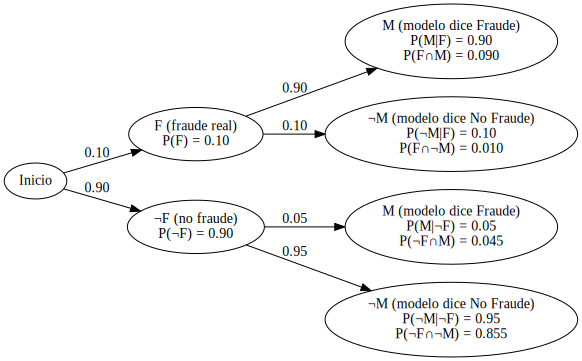

In [ ]:
from graphviz import Digraph

# Parámetros (ajusta si quieres)
p_F = 0.10
p_notF = 1 - p_F

p_M_given_F = 0.90
p_notM_given_F = 1 - p_M_given_F

p_M_given_notF = 0.05
p_notM_given_notF = 1 - p_M_given_notF

# Probabilidades conjuntas (para mostrar en hojas)
p_F_M = p_F * p_M_given_F
p_F_notM = p_F * p_notM_given_F
p_notF_M = p_notF * p_M_given_notF
p_notF_notM = p_notF * p_notM_given_notF

dot = Digraph("ArbolProb", format="png")
dot.attr(rankdir="LR", fontsize="12")

# Nodos
dot.node("S", "Inicio")
dot.node("F",  f"F (fraude real)\nP(F) = {p_F:.2f}")
dot.node("nF", f"¬F (no fraude)\nP(¬F) = {p_notF:.2f}")

dot.node("FM",  f"M (modelo dice Fraude)\nP(M|F) = {p_M_given_F:.2f}\nP(F∩M) = {p_F_M:.3f}")
dot.node("FnM", f"¬M (modelo dice No Fraude)\nP(¬M|F) = {p_notM_given_F:.2f}\nP(F∩¬M) = {p_F_notM:.3f}")

dot.node("nFM",  f"M (modelo dice Fraude)\nP(M|¬F) = {p_M_given_notF:.2f}\nP(¬F∩M) = {p_notF_M:.3f}")
dot.node("nFnM", f"¬M (modelo dice No Fraude)\nP(¬M|¬F) = {p_notM_given_notF:.2f}\nP(¬F∩¬M) = {p_notF_notM:.3f}")

# Aristas
dot.edge("S", "F",  label=f"{p_F:.2f}")
dot.edge("S", "nF", label=f"{p_notF:.2f}")

dot.edge("F",  "FM",  label=f"{p_M_given_F:.2f}")
dot.edge("F",  "FnM", label=f"{p_notM_given_F:.2f}")

dot.edge("nF", "nFM",  label=f"{p_M_given_notF:.2f}")
dot.edge("nF", "nFnM", label=f"{p_notM_given_notF:.2f}")

dot


# **PARTE 2**

## Live Coding

Modelaremos un test diagnóstico con sensibilidad y tasa de falsos positivos, analizando cómo la prevalencia de la enfermedad influye en la probabilidad real de padecerla dado un resultado positivo.

0. Setup

In [13]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")  # opción controla el formato de visualización de números en pandas


1. Simularemos un test de diagnóstico con falso positivo/falso negativo

Simularemos 50,000 individuos evaluados con una prueba diagnóstica:

Parámetros:
* Prevalencia (10%): 10% de la población tiene la condición
* Sensibilidad (90%): La prueba detecta correctamente el 90% de los casos positivos
* Tasa de falsos positivos (5%): La prueba da positivo en el 5% de los sanos

In [15]:
# -----------------------------
# Parámetros del problema
# -----------------------------
N = 50000

prev = 0.10              # Prevalencia: P(E)
sens = 0.90              # Sensibilidad: P(T+ | E)
fpr  = 0.05              # Tasa falsos positivos: P(T+ | no E)

# Derivadas
spec = 1 - fpr           # Especificidad: P(T- | no E)

In [17]:
# -----------------------------
# 1) Simular "realidad": enfermo / sano
# -----------------------------
rng = np.random.default_rng(42)
E = rng.random(N) < prev          # True si enfermo, False si sano

In [18]:
# -----------------------------
# 2) Simular resultado del test condicionado a la realidad
# -----------------------------
T_pos = np.empty(N, dtype=bool)

# Si está enfermo: positivo con prob sens
T_pos[E] = rng.random(E.sum()) < sens

# Si está sano: positivo con prob fpr
T_pos[~E] = rng.random((~E).sum()) < fpr

In [19]:
# -----------------------------
# 3) Contar la tabla de contingencia
# -----------------------------
TP = np.sum(T_pos & E)        # Verdadero positivo
FN = np.sum((~T_pos) & E)     # Falso negativo
FP = np.sum(T_pos & (~E))     # Falso positivo
TN = np.sum((~T_pos) & (~E))  # Verdadero negativo

contingencia = pd.DataFrame(
    [[TP, FN],
     [FP, TN]],
    index=["Test +", "Test -"],
    columns=["Enfermo (E)", "Sano (¬E)"]
)

contingencia

,Enfermo (E),Sano (¬E)
Test +,4442,499
Test -,2291,42768


Verdaderos Positivos (VP), Falsos Positivos (FP), etc.
* VP = 4442  # Tienen condición Y test +
* FP = 2291  # NO tienen condición pero test +
* VN = 42768 # NO tienen condición Y test -
* FN = 499   # Tienen condición pero test

Conclusión importante: Solo el 66% de los que dieron positivo realmente tienen la condición.

Esto ocurre porque:
* Aunque la prueba es bastante buena (90% sensibilidad, 95% especificidad)
* La condición es rara (solo 10% de prevalencia)
* Hay muchas más personas sanas (45,059) que enfermas (4,941)
* Por lo tanto, incluso un pequeño 5% de falsos positivos en sanos genera 2,291 falsos positivos

La probabilidad real de estar enfermo si el test dio positivo.

In [20]:
# -----------------------------
# 4) Probabilidad posterior (desde la simulación)
# -----------------------------
p_E_given_Tpos_sim = TP / (TP + FP)

p_E_given_Tpos_sim


np.float64(0.6597356304767563)

 Ahora la misma probabilidad, pero por Bayes (teórico):


In [21]:
# -----------------------------
# 5) Probabilidad posterior (Bayes teórico)
# -----------------------------
# P(T+) = P(T+|E)P(E) + P(T+|¬E)P(¬E)
p_Tpos = sens*prev + fpr*(1-prev)

p_E_given_Tpos_bayes = (sens*prev) / p_Tpos

p_E_given_Tpos_bayes


0.6666666666666667

In [22]:
resultados = pd.DataFrame({
    "Métrica": [
        "Prevalencia P(E)",
        "Sensibilidad P(T+|E)",
        "Falsos Positivos P(T+|¬E)",
        "P(T+) total",
        "P(E|T+) Bayes",
        "P(E|T+) Simulación"
    ],
    "Valor": [
        prev,
        sens,
        fpr,
        p_Tpos,
        p_E_given_Tpos_bayes,
        p_E_given_Tpos_sim
    ]
})

resultados


,Métrica,Valor
0,Prevalencia P(E),0.1000
1,Sensibilidad P(T+|E),0.9000
2,Falsos Positivos P(T+|¬E),0.0500
3,P(T+) total,0.1350
4,P(E|T+) Bayes,0.6667
5,P(E|T+) Simulación,0.6597


### **árbol de probabilidades**

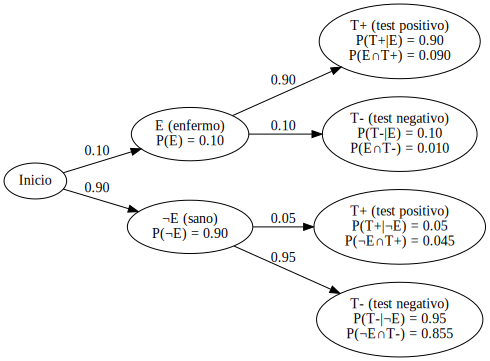

In [23]:
from graphviz import Digraph

# -----------------------------
# Parámetros del test (caso diagnóstico)
# -----------------------------
p_E = 0.10                 # Prevalencia: P(E) = prob. de enfermedad
p_notE = 1 - p_E

p_Tpos_given_E = 0.90      # Sensibilidad: P(T+ | E)
p_Tneg_given_E = 1 - p_Tpos_given_E

p_Tpos_given_notE = 0.05   # Falsos positivos: P(T+ | ¬E)
p_Tneg_given_notE = 1 - p_Tpos_given_notE  # Especificidad

# -----------------------------
# Probabilidades conjuntas (hojas del árbol)
# -----------------------------
p_E_Tpos   = p_E * p_Tpos_given_E
p_E_Tneg   = p_E * p_Tneg_given_E
p_notE_Tpos = p_notE * p_Tpos_given_notE
p_notE_Tneg = p_notE * p_Tneg_given_notE

# -----------------------------
# Construcción del árbol
# -----------------------------
dot = Digraph("ArbolDiagnostico", format="png")
dot.attr(rankdir="LR", fontsize="12")

# Nodos
dot.node("S", "Inicio")

dot.node("E",  f"E (enfermo)\nP(E) = {p_E:.2f}")
dot.node("nE", f"¬E (sano)\nP(¬E) = {p_notE:.2f}")

dot.node("ETp",  f"T+ (test positivo)\nP(T+|E) = {p_Tpos_given_E:.2f}\nP(E∩T+) = {p_E_Tpos:.3f}")
dot.node("ETn",  f"T- (test negativo)\nP(T-|E) = {p_Tneg_given_E:.2f}\nP(E∩T-) = {p_E_Tneg:.3f}")

dot.node("nETp", f"T+ (test positivo)\nP(T+|¬E) = {p_Tpos_given_notE:.2f}\nP(¬E∩T+) = {p_notE_Tpos:.3f}")
dot.node("nETn", f"T- (test negativo)\nP(T-|¬E) = {p_Tneg_given_notE:.2f}\nP(¬E∩T-) = {p_notE_Tneg:.3f}")

# Aristas
dot.edge("S", "E",  label=f"{p_E:.2f}")
dot.edge("S", "nE", label=f"{p_notE:.2f}")

dot.edge("E",  "ETp", label=f"{p_Tpos_given_E:.2f}")
dot.edge("E",  "ETn", label=f"{p_Tneg_given_E:.2f}")

dot.edge("nE", "nETp", label=f"{p_Tpos_given_notE:.2f}")
dot.edge("nE", "nETn", label=f"{p_Tneg_given_notE:.2f}")

dot
